In [1]:
import os

import scipy as sc
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

In [2]:
INPUT_DIR = "/Users/willtrim/Desktop/RNAseq Bed Rest Data/"

work_dir = os.path.join(INPUT_DIR, "workdir")

In [3]:
deseq_results_dir = "/Users/willtrim/Desktop/RNAseq Bed Rest Data/outputs/deseq2_results"

In [4]:
norm_counts_fp = os.path.join(deseq_results_dir, "normalized_counts.csv")
norm_counts = pd.read_csv(norm_counts_fp, index_col=0)
norm_counts

,Pre_A1_Pre_BR_289105.bam,Pre_A2_Pre_BR_203130.bam,Pre_B1_Pre_BR_290117.bam,Pre_B2_Pre_BR_204142.bam,Pre_C1_Pre_BR_291129.bam,Pre_C2_Pre_BR_205154.bam,Pre_D1_Pre_BR_292141.bam,Pre_D2_Pre_BR_206166.bam,Pre_E1_Pre_BR_293153.bam,Pre_E2_Pre_BR_207178.bam,...,Post_E2_Post_BR_227133.bam,Post_F1_Post_BR_218120.bam,Post_F2_Post_BR_228145.bam,Post_G1_Post_BR_219132.bam,Post_G2_Post_BR_229157.bam,Post_H1_Post_BR_220144.bam,Post_H2_Post_BR_230169.bam,Post_I1_Post_BR_221156.bam,Post_J1_Post_BR_222168.bam,Post_J2_Post_BR_232193.bam
ENSG00000223972.5,0.000000e+00,0.000000,0.000000,0.000000,0.000000,4.146055,0.000000e+00,1.077489e+00,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000
ENSG00000227232.5,9.336864e+01,169.697094,81.084642,52.177652,38.674840,116.089545,1.844144e+02,4.740953e+01,182.365513,49.380718,...,50.010686,87.512305,83.778743,145.776991,79.486137,1.065565e+02,56.820078,56.030609,6.229714e+01,104.558367
ENSG00000278267.1,3.844591e+01,6.787884,12.387931,7.023915,16.035909,22.803303,1.410228e+01,1.400736e+01,19.196370,18.042955,...,13.046266,6.731716,16.755749,24.990341,15.712376,1.291594e+01,6.520337,11.592540,1.891163e+01,14.388766
ENSG00000243485.5,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.000000,1.121953,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000
ENSG00000284332.1,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000198695.2,2.671441e+05,163418.301532,223221.515121,176915.351389,192553.540181,175803.104497,2.597130e+05,2.551258e+05,182653.458779,178291.931625,...,189755.762440,221410.619849,280927.866269,147511.737273,192410.982244,2.348225e+05,194047.088138,208241.620942,2.705020e+05,244840.203004
ENSG00000210194.1,1.208300e+01,6.787884,7.883229,4.013666,6.603022,5.182569,3.254372e+00,6.464937e+00,8.638366,5.697775,...,4.348755,5.609763,7.885058,3.123793,3.697030,8.610625e+00,3.725907,10.626495,1.112449e+01,12.470264
ENSG00000198727.2,1.065704e+06,830387.032553,848065.398364,721379.110822,861397.171363,815603.681635,1.088867e+06,1.188804e+06,781714.571559,825576.283875,...,976499.952759,777709.514421,894661.367666,604830.818514,836148.870530,1.078017e+06,883996.533802,801899.443405,1.132391e+06,972274.824344
ENSG00000210195.2,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000


In [10]:
samples_fp = os.path.join(INPUT_DIR, "samples.csv")
samples = pd.read_csv(samples_fp, index_col=0)
samples

,patient,tmp,group,total,n_genes_by_counts,total_counts,total_counts_rprot,pct_counts_rprot,total_counts_rRNA,pct_counts_rRNA,total_counts_mt,pct_counts_mt,tmp:group,FFA (mmol/l) Arter.,TAG (mmol/l) Arter.,INS (mIU/l) Arter.,Glucose (mmol/l) Arter.,GD mg/kg/min,Insulin (mIU/l) Venous
name,,,,,,,,,,,,,,,,,,,
Pre_A1_Pre_BR_289105.bam,A1,Pre,Cocktail,49269604,28411,49269604,1391011,2.823264,6437,0.013065,10257548,20.819222,Pre:Cocktail,0.4150,0.58,4.697732,4.3,8.520406,2.8600
Pre_A2_Pre_BR_203130.bam,A2,Pre,Control,51010613,29593,51010613,1101490,2.159335,6814,0.013358,8698360,17.052059,Pre:Control,0.4795,0.94,21.947574,4.4,7.820128,7.1990
Pre_B1_Pre_BR_290117.bam,B1,Pre,Cocktail,43730612,29074,43730612,1247977,2.853784,5730,0.013103,7576403,17.325170,Pre:Cocktail,0.3902,0.46,5.902004,4.2,6.175030,3.2250
Pre_B2_Pre_BR_204142.bam,B2,Pre,Control,48593125,29644,48593125,923150,1.899754,7163,0.014741,8053423,16.573174,Pre:Control,0.4023,0.46,26.112456,4.6,7.417069,4.5270
Pre_C1_Pre_BR_291129.bam,C1,Pre,Control,51935425,29823,51935425,1143645,2.202052,7093,0.013657,8809183,16.961800,Pre:Control,0.5538,0.51,12.620836,4.3,6.301969,3.6185
Pre_C2_Pre_BR_205154.bam,C2,Pre,Cocktail,50054273,29123,50054273,1084242,2.166133,6959,0.013903,7902793,15.788448,Pre:Cocktail,0.2767,0.42,22.460194,4.1,6.683051,3.6575
Pre_D1_Pre_BR_292141.bam,D1,Pre,Control,47371511,28971,47371511,1020863,2.155015,5900,0.012455,10255908,21.649949,Pre:Control,0.9491,0.40,12.573115,4.6,4.914221,6.6300
Pre_D2_Pre_BR_206166.bam,D2,Pre,Control,46912722,29100,46912722,1347793,2.872980,5987,0.012762,10607772,22.611717,Pre:Control,0.4732,0.34,26.722870,4.3,7.504336,4.2795
Pre_E1_Pre_BR_293153.bam,E1,Pre,Control,50558345,29206,50558345,1264149,2.500377,7378,0.014593,8728047,17.263316,Pre:Control,0.4270,1.24,19.938857,4.4,5.444510,2.8600


In [17]:
gene_names = pd.read_csv(os.path.join(work_dir, "gProfiler_hsapiens_07-08-2025_22-53-39.csv"))
gene_names.drop_duplicates(["initial_alias", "name"], keep="first", inplace=True)

In [21]:
def draw_vals(gene_id, pheno_name, title, connect_ids=False):
    
    data = pd.concat([samples.loc[:,["tmp", "patient", pheno_name]], norm_counts.loc[gene_id, :]], axis=1)
    # data[[gene_name, pheno_name]] = data[[gene_name, pheno_name]].astype(np.float32)

    lm = sns.lmplot(data=data, x=pheno_name, y=gene_id, hue="tmp") #, ci=99, marker="x", line_kws=dict(color="r"))
    
    # if connect_ids:
    #     data["id"] = pheno_vals.loc[data.index, "id"]
    #     for patient_id, patient_data in data.groupby("id"):
            
    #         sns.lineplot(patient_data, x=pheno_name, y=gene_name, ax=lm.axes[0,0], color="black",  linewidth=0.1)  
    
    plt.title(title)
    
    plt.show()

# Plain GD

In [8]:
pheno_name = "GD mg/kg/min"

In [18]:
results_fp = os.path.join(deseq_results_dir, "deseq2_results_GD.csv")
results_df = pd.read_csv(results_fp, index_col=0)
results_df["gene_id"] = results_df.index.to_series().str.split(".", expand=True).iloc[:,0]
results_df["gene_name"] = gene_names.set_index("initial_alias").loc[results_df.gene_id, "name"].values

results_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_id,gene_name
ENSG00000223972.5,0.504006,-0.136666,2.100252,0.006593,0.935283,NaN,ENSG00000223972,NaN
ENSG00000227232.5,84.283295,0.073814,0.128176,0.313270,0.575681,0.830853,ENSG00000227232,NaN
ENSG00000278267.1,14.634417,0.136009,0.139637,0.938121,0.332762,NaN,ENSG00000278267,MIR6859-1
ENSG00000243485.5,0.055123,0.055201,2.107427,0.000670,0.979351,NaN,ENSG00000243485,NaN
ENSG00000284332.1,0.000000,NaN,NaN,NaN,NaN,NaN,ENSG00000284332,MIR1302-2
...,...,...,...,...,...,...,...,...
ENSG00000198695.2,210370.483873,0.036834,0.034855,1.112347,0.291572,0.635385,ENSG00000198695,MT-ND6
ENSG00000210194.1,6.872186,0.128695,0.182529,0.490141,0.483864,NaN,ENSG00000210194,NaN
ENSG00000198727.2,867322.680673,0.044431,0.039323,1.268937,0.259966,0.605865,ENSG00000198727,MT-CYB
ENSG00000210195.2,0.025263,-0.085833,2.107485,0.003862,0.950448,NaN,ENSG00000210195,NaN


In [37]:
samples

,patient,tmp,group,total,n_genes_by_counts,total_counts,total_counts_rprot,pct_counts_rprot,total_counts_rRNA,pct_counts_rRNA,total_counts_mt,pct_counts_mt,tmp:group,FFA (mmol/l) Arter.,TAG (mmol/l) Arter.,INS (mIU/l) Arter.,Glucose (mmol/l) Arter.,GD mg/kg/min,Insulin (mIU/l) Venous
name,,,,,,,,,,,,,,,,,,,
Pre_A1_Pre_BR_289105.bam,A1,Pre,Cocktail,49269604,28411,49269604,1391011,2.823264,6437,0.013065,10257548,20.819222,Pre:Cocktail,0.4150,0.58,4.697732,4.3,8.520406,2.8600
Pre_A2_Pre_BR_203130.bam,A2,Pre,Control,51010613,29593,51010613,1101490,2.159335,6814,0.013358,8698360,17.052059,Pre:Control,0.4795,0.94,21.947574,4.4,7.820128,7.1990
Pre_B1_Pre_BR_290117.bam,B1,Pre,Cocktail,43730612,29074,43730612,1247977,2.853784,5730,0.013103,7576403,17.325170,Pre:Cocktail,0.3902,0.46,5.902004,4.2,6.175030,3.2250
Pre_B2_Pre_BR_204142.bam,B2,Pre,Control,48593125,29644,48593125,923150,1.899754,7163,0.014741,8053423,16.573174,Pre:Control,0.4023,0.46,26.112456,4.6,7.417069,4.5270
Pre_C1_Pre_BR_291129.bam,C1,Pre,Control,51935425,29823,51935425,1143645,2.202052,7093,0.013657,8809183,16.961800,Pre:Control,0.5538,0.51,12.620836,4.3,6.301969,3.6185
Pre_C2_Pre_BR_205154.bam,C2,Pre,Cocktail,50054273,29123,50054273,1084242,2.166133,6959,0.013903,7902793,15.788448,Pre:Cocktail,0.2767,0.42,22.460194,4.1,6.683051,3.6575
Pre_D1_Pre_BR_292141.bam,D1,Pre,Control,47371511,28971,47371511,1020863,2.155015,5900,0.012455,10255908,21.649949,Pre:Control,0.9491,0.40,12.573115,4.6,4.914221,6.6300
Pre_D2_Pre_BR_206166.bam,D2,Pre,Control,46912722,29100,46912722,1347793,2.872980,5987,0.012762,10607772,22.611717,Pre:Control,0.4732,0.34,26.722870,4.3,7.504336,4.2795
Pre_E1_Pre_BR_293153.bam,E1,Pre,Control,50558345,29206,50558345,1264149,2.500377,7378,0.014593,8728047,17.263316,Pre:Control,0.4270,1.24,19.938857,4.4,5.444510,2.8600


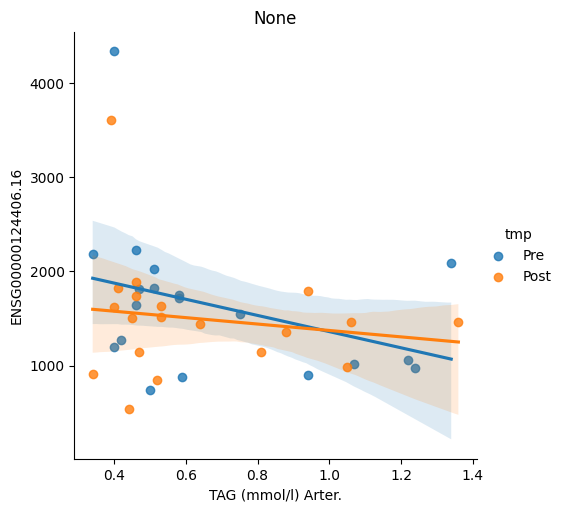

In [38]:
draw_vals("ENSG00000124406.16", "TAG (mmol/l) Arter.", "None")

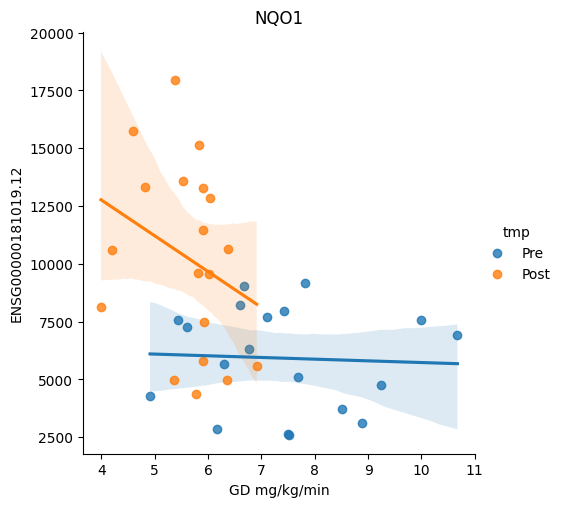

In [42]:
draw_vals("ENSG00000181019.12", "GD mg/kg/min", "NQO1")

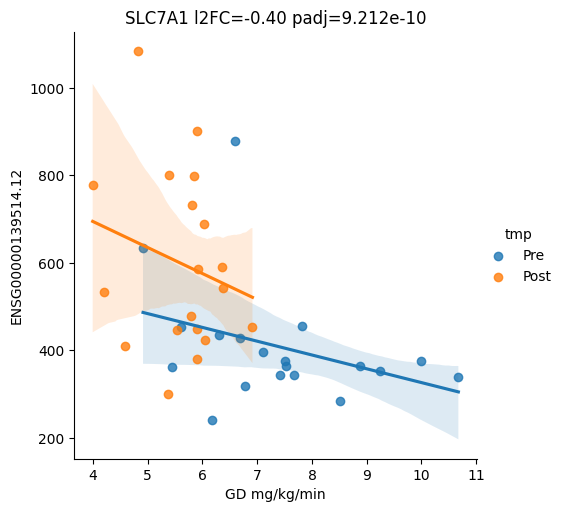

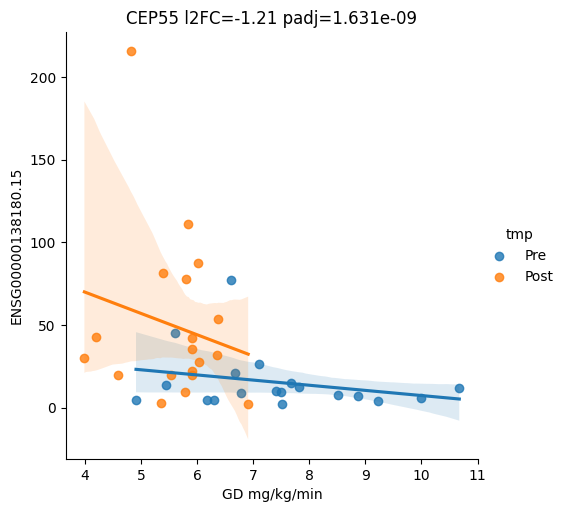

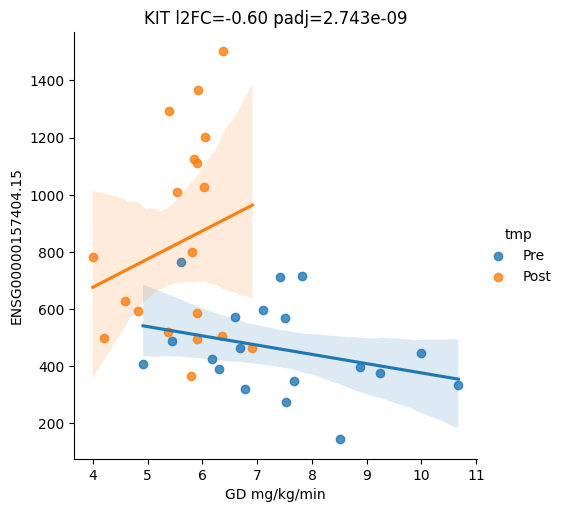

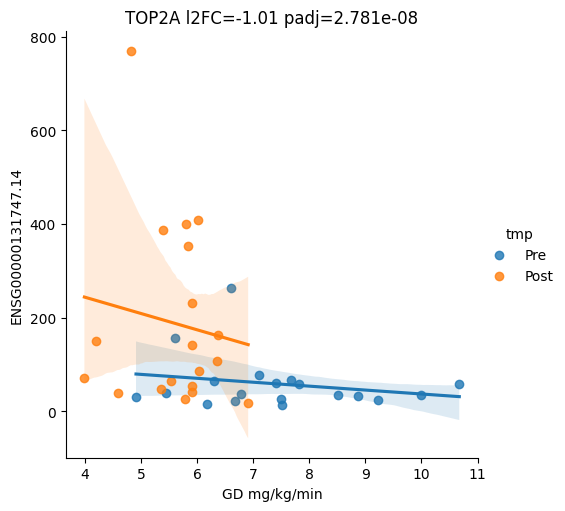

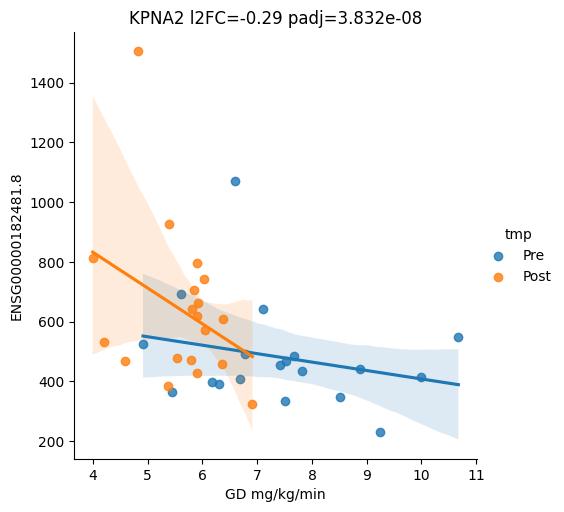

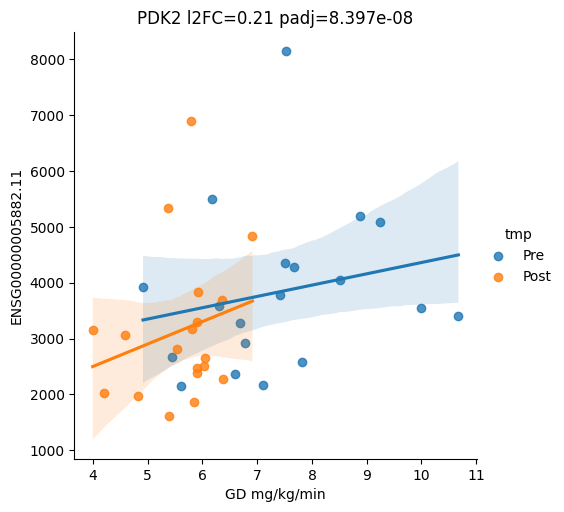

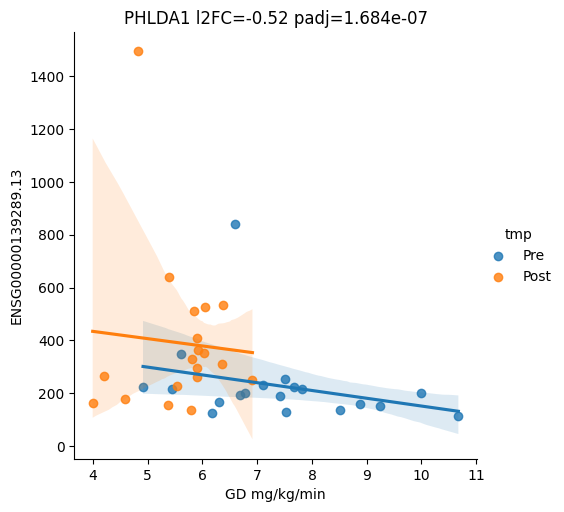

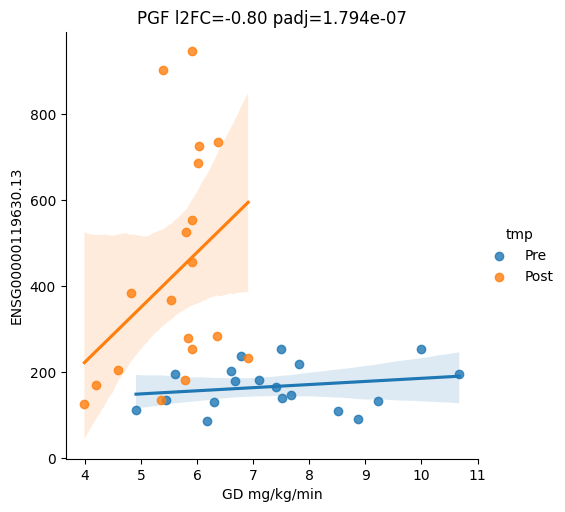

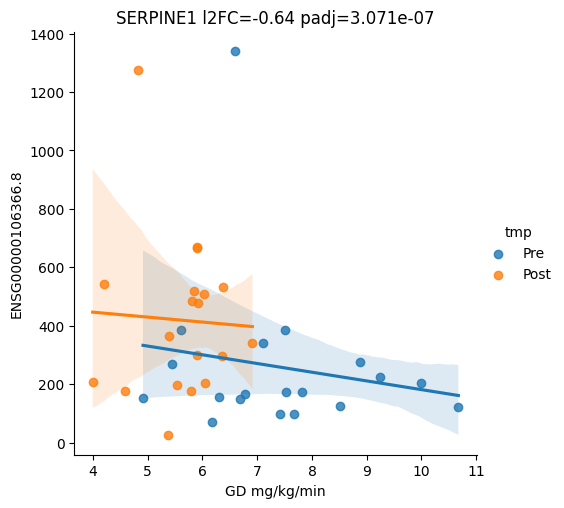

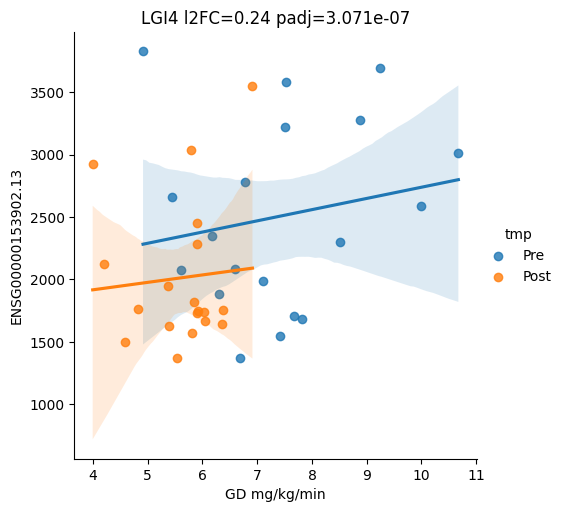

In [24]:
n_top = 10

for gene_id, gene_results in results_df.sort_values("padj").iloc[:n_top,:].iterrows():
    title = f"{gene_results.gene_name} l2FC={gene_results.log2FoldChange:.2f} padj={gene_results.padj:.3e}"
    draw_vals(gene_id, pheno_name, title=title)